<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h1 align="center"><font color="#FF0000">Welcome to CI&T DeskDrop Articles Recommendation System Notebook</font></h1>

Welcome! In this Notebook I will create multiple Recommendation Systems (RecSys) on CI&T DeskDrop data where we have **Shared Articles** and **User Interactions**. Given CI&T DeskDrop data contains users, products and their interactions with products mentioned as **personId**, **contentId** and **interactionType** respectively.

Motive of this Notebook is to implement **Content-Based Filtering**, **Collaborative Filtering**, **Popularity Based** and **Hybrid** Recommendation Systems and to evaluate all of the mentioned RecSys and find out which model is performing better among all other so that we can enhance our RecSys pipeline.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import random
from scipy.sparse.linalg import svds
from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import math
from tqdm.notebook import tqdm

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h2><font color="#FF0000">Importing Data</font></h2>

We will start this project by importing **Shared Articles** and **Users Interactions**. **Shared Articles** contain all the articles where a particular **ContentId** (i.e product) is mentioned. Moreover **ContentId** title and textual description can also be found. **User Interactions** contain each **PersonId** that represent an user who have interacted with mentioned **ContentId** with various interactions like **Like**, **Follow**, **Comment**, **Bookmark** and **View**.

In [2]:
articles = pd.read_csv("/kaggle/input/datasets/gspmoreira/articles-sharing-reading-from-cit-deskdrop/shared_articles.csv")
interactions = pd.read_csv("/kaggle/input/datasets/gspmoreira/articles-sharing-reading-from-cit-deskdrop/users_interactions.csv")

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">
    
Let's view top 5 rows of both `articles` and `interactions` DataFrames.

In [3]:
articles.head(5)

,timestamp,eventType,contentId,authorPersonId,authorSessionId,authorUserAgent,authorRegion,authorCountry,contentType,url,title,text,lang
0,1459192779,CONTENT REMOVED,-6451309518266745024,4340306774493623681,8940341205206233829,NaN,NaN,NaN,HTML,http://www.nytimes.com/2016/03/28/business/dea...,"Ethereum, a Virtual Currency, Enables Transact...",All of this work is still very early. The firs...,en
1,1459193988,CONTENT SHARED,-4110354420726924665,4340306774493623681,8940341205206233829,NaN,NaN,NaN,HTML,http://www.nytimes.com/2016/03/28/business/dea...,"Ethereum, a Virtual Currency, Enables Transact...",All of this work is still very early. The firs...,en
2,1459194146,CONTENT SHARED,-7292285110016212249,4340306774493623681,8940341205206233829,NaN,NaN,NaN,HTML,http://cointelegraph.com/news/bitcoin-future-w...,Bitcoin Future: When GBPcoin of Branson Wins O...,The alarm clock wakes me at 8:00 with stream o...,en
3,1459194474,CONTENT SHARED,-6151852268067518688,3891637997717104548,-1457532940883382585,NaN,NaN,NaN,HTML,https://cloudplatform.googleblog.com/2016/03/G...,Google Data Center 360° Tour,We're excited to share the Google Data Center ...,en
4,1459194497,CONTENT SHARED,2448026894306402386,4340306774493623681,8940341205206233829,NaN,NaN,NaN,HTML,https://bitcoinmagazine.com/articles/ibm-wants...,"IBM Wants to ""Evolve the Internet"" With Blockc...",The Aite Group projects the blockchain market ...,en


In [4]:
interactions.head(5)

,timestamp,eventType,contentId,personId,sessionId,userAgent,userRegion,userCountry
0,1465413032,VIEW,-3499919498720038879,-8845298781299428018,1264196770339959068,NaN,NaN,NaN
1,1465412560,VIEW,8890720798209849691,-1032019229384696495,3621737643587579081,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2...,NY,US
2,1465416190,VIEW,310515487419366995,-1130272294246983140,2631864456530402479,NaN,NaN,NaN
3,1465413895,FOLLOW,310515487419366995,344280948527967603,-3167637573980064150,NaN,NaN,NaN
4,1465412290,VIEW,-7820640624231356730,-445337111692715325,5611481178424124714,NaN,NaN,NaN


<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">


In **shared_articles** table, `eventType = CONTENT REMOVED` means that such ContentId is not available for recommendation anymore. So I will remove such **ContenIds** as they are irrelevant. 

In [5]:
#
articles = articles[articles["eventType"]!="CONTENT REMOVED"].reset_index(drop=True)
articles.head(5)

,timestamp,eventType,contentId,authorPersonId,authorSessionId,authorUserAgent,authorRegion,authorCountry,contentType,url,title,text,lang
0,1459193988,CONTENT SHARED,-4110354420726924665,4340306774493623681,8940341205206233829,NaN,NaN,NaN,HTML,http://www.nytimes.com/2016/03/28/business/dea...,"Ethereum, a Virtual Currency, Enables Transact...",All of this work is still very early. The firs...,en
1,1459194146,CONTENT SHARED,-7292285110016212249,4340306774493623681,8940341205206233829,NaN,NaN,NaN,HTML,http://cointelegraph.com/news/bitcoin-future-w...,Bitcoin Future: When GBPcoin of Branson Wins O...,The alarm clock wakes me at 8:00 with stream o...,en
2,1459194474,CONTENT SHARED,-6151852268067518688,3891637997717104548,-1457532940883382585,NaN,NaN,NaN,HTML,https://cloudplatform.googleblog.com/2016/03/G...,Google Data Center 360° Tour,We're excited to share the Google Data Center ...,en
3,1459194497,CONTENT SHARED,2448026894306402386,4340306774493623681,8940341205206233829,NaN,NaN,NaN,HTML,https://bitcoinmagazine.com/articles/ibm-wants...,"IBM Wants to ""Evolve the Internet"" With Blockc...",The Aite Group projects the blockchain market ...,en
4,1459194522,CONTENT SHARED,-2826566343807132236,4340306774493623681,8940341205206233829,NaN,NaN,NaN,HTML,http://www.coindesk.com/ieee-blockchain-oxford...,IEEE to Talk Blockchain at Cloud Computing Oxf...,One of the largest and oldest organizations fo...,en


<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">


All the **ContentIds** which are available in `interaction` DataFrame but not available in `articles` DataFrame will be removed from `interaction` DataFrame.

In [6]:
records_before_removal = len(interactions)
interactions = interactions[interactions["contentId"].isin(articles["contentId"].unique().tolist())].reset_index(drop=True)
records_after_removal = len(interactions)
num_removed = records_before_removal - records_after_removal
print(f"Number of records Removed: {num_removed} ({num_removed*100/records_before_removal:.2f}%)")

Number of records Removed: 43 (0.06%)


In [7]:
interactions.eventType.unique()

array(['VIEW', 'FOLLOW', 'BOOKMARK', 'LIKE', 'COMMENT CREATED'],
      dtype=object)

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">


Since `interactions.eventType` is **Interaction Type** which stores 5 distinct interactions, we would like to map a numeric value which let us understand the strength of such interaction. For this I will implement a dictionary `event_mappings` which contains unique interactions as its keys and their corresponding strength as its values. Afterwards I will create `interactions.eventStrength` column with `event_mappings` which will let us understand how much a user interact with a product.

In [8]:
event_mappings = {
    'VIEW'            : 1, 
    'FOLLOW'          : 3,
    'BOOKMARK'        : 2.5,
    'LIKE'            : 2, 
    'COMMENT CREATED' : 4
}
interactions.loc[:, "eventStrength"] = interactions["eventType"].map(event_mappings)

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">


In `interactions` DataFrame there are users who have only one product such users are difficult to provide recommendations. To get around this I would like to create my recommendation pipeline which includes users that have atleast 5 products.

In [9]:
personId_nunique = interactions.groupby("personId")["contentId"].nunique().reset_index().rename(columns={"contentId":"nunique"})
personId_nunique = personId_nunique[personId_nunique["nunique"]>=5]
print(f"Number of Users who are selected for recommendation system: {len(personId_nunique)}")
print(f"Number of Users who are unselected: {interactions.personId.nunique() - len(personId_nunique)}")

Number of Users who are selected for recommendation system: 1139
Number of Users who are unselected: 756


In [10]:
selected_interactions = interactions[interactions.personId.isin(personId_nunique.personId)].reset_index(drop=True)
selected_interactions.head(5)

,timestamp,eventType,contentId,personId,sessionId,userAgent,userRegion,userCountry,eventStrength
0,1465413032,VIEW,-3499919498720038879,-8845298781299428018,1264196770339959068,NaN,NaN,NaN,1.0
1,1465412560,VIEW,8890720798209849691,-1032019229384696495,3621737643587579081,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2...,NY,US,1.0
2,1465416190,VIEW,310515487419366995,-1130272294246983140,2631864456530402479,NaN,NaN,NaN,1.0
3,1465413895,FOLLOW,310515487419366995,344280948527967603,-3167637573980064150,NaN,NaN,NaN,3.0
4,1465412290,VIEW,-7820640624231356730,-445337111692715325,5611481178424124714,NaN,NaN,NaN,1.0


In [11]:
selected_interactions = selected_interactions.groupby(["personId", "contentId"])["eventStrength"].sum().apply(lambda x: math.log(x+1, 2)).reset_index()
selected_interactions.head(5)

,personId,contentId,eventStrength
0,-9223121837663643404,-8949113594875411859,1.000000
1,-9223121837663643404,-8377626164558006982,1.000000
2,-9223121837663643404,-8208801367848627943,1.000000
3,-9223121837663643404,-8187220755213888616,1.000000
4,-9223121837663643404,-7423191370472335463,3.169925


<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h2><font color="#FF0000">Train-Test Split</font></h2>

Let's begin our Recommender System pipeline by splitting our `interactions` DataFrame into Train-Test split where **80%** of `interactions` records will be used as training our Recommender System models whereas remaining **20%** of the records will be used for model's evaluation. We will use **personId** column of `interactions` for stratification as it will make sure that on approx. **20%** of each **personId** records will be used as testing or model evaluation.

In [12]:
train_interactions, test_interactions = train_test_split(
    selected_interactions,
    stratify=selected_interactions["personId"],
    test_size=.2,
    shuffle=True,
    random_state=44
)

In [13]:
len(train_interactions), len(test_interactions)

(31260, 7815)

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h2><font color="#FF0000">Content Based Filtering</font></h2>

In **Content Based Filtering**, we will create contents Unit Vector of each **personId**. This Unit Vector is formed with **TfidfVectorizer** which utilizes textual title and description of each **contentId** of a **personId**. After obtaining Unit Vector of each **personId** we will **normalize** it and will use **Cosine Similarity** to find highly similar and not interacted **contentId** Unit Vector.

In [14]:
articles.head(5)

,timestamp,eventType,contentId,authorPersonId,authorSessionId,authorUserAgent,authorRegion,authorCountry,contentType,url,title,text,lang
0,1459193988,CONTENT SHARED,-4110354420726924665,4340306774493623681,8940341205206233829,NaN,NaN,NaN,HTML,http://www.nytimes.com/2016/03/28/business/dea...,"Ethereum, a Virtual Currency, Enables Transact...",All of this work is still very early. The firs...,en
1,1459194146,CONTENT SHARED,-7292285110016212249,4340306774493623681,8940341205206233829,NaN,NaN,NaN,HTML,http://cointelegraph.com/news/bitcoin-future-w...,Bitcoin Future: When GBPcoin of Branson Wins O...,The alarm clock wakes me at 8:00 with stream o...,en
2,1459194474,CONTENT SHARED,-6151852268067518688,3891637997717104548,-1457532940883382585,NaN,NaN,NaN,HTML,https://cloudplatform.googleblog.com/2016/03/G...,Google Data Center 360° Tour,We're excited to share the Google Data Center ...,en
3,1459194497,CONTENT SHARED,2448026894306402386,4340306774493623681,8940341205206233829,NaN,NaN,NaN,HTML,https://bitcoinmagazine.com/articles/ibm-wants...,"IBM Wants to ""Evolve the Internet"" With Blockc...",The Aite Group projects the blockchain market ...,en
4,1459194522,CONTENT SHARED,-2826566343807132236,4340306774493623681,8940341205206233829,NaN,NaN,NaN,HTML,http://www.coindesk.com/ieee-blockchain-oxford...,IEEE to Talk Blockchain at Cloud Computing Oxf...,One of the largest and oldest organizations fo...,en


<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

As `articles.title` and `articles.text` contain **Stopwords** like a, am, are, because and many more, Such **Stopwords** provide no useful information about a **contentId**. So it is better to create a list of all english and portuguese (as some **contentId** have portuguese text and title) **Stopwords** which will be given as parameter to **TfidfVectorizer** for exclusion. 

I will use `nltk.corpus.stopwords` to have list of **Stopwords**.

In [15]:
STOPWORDS = stopwords.words("english")
STOPWORDS.extend(stopwords.words("portuguese"))

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h3 align="center"><font color="#FF0000">Term-Frequency Inverse Document Frequency (Tfidf) Vectorizer</font></h3>

Now I will implement **Scikit-Learn's TfidfVectorizer** with **UniGrams and BiGrams**. To save our time during tfidf-matrix generation, I would use `max_features=5000` to limit maximum features given to a single **contentId**.

In [16]:
vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1,2),
    min_df = .01,
    max_df = .5,
    stop_words = STOPWORDS,
    max_features=5000
)

tfidf_matrix = vectorizer.fit_transform(articles["title"] + " " + articles["text"],)
tfidf_matrix.shape

(3047, 5000)

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

I will create **contentId** to matrix indices dictionary `articles_mapping` and matrix indices to **contentId** dictionary `reverse_articles_mapping`. Both of this dictionaries help us saving time and help us fetch relevant **contentId** or matrix indices.

In [17]:
articles_mapping = {c:i for i, c in enumerate(articles["contentId"])}
reverse_articles_mapping = {i:c for i, c in enumerate(articles["contentId"])}

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

Let's train our **Content Based Recommendation System**.

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h3 align="center"><font color="#FF0000">Utility Functions</font></h3>

I will create some **utility functions** required for all of the recommender systems that I will develop.

In [18]:
def getPersonTrainInteractions(pid):
    """returns `pid` training contentIds"""
    person_train_interactions = train_interactions[train_interactions["personId"]==pid]["contentId"].unique().tolist()
    return person_train_interactions
    
def getInteractionsStrength(pid):
    """returns `pid` training contentIds eventStrength"""
    interactions_strength = train_interactions[train_interactions["personId"]==(pid)]["eventStrength"].values.reshape(-1, 1)
    return interactions_strength

def getMatrixIndices(cids):
    """returns list that holds each `cids` `tfidf_matrix` index"""
    matrix_indices = list(map(lambda x: articles_mapping[x], cids))
    return matrix_indices
    
def getInteractionVectors(matrix_indices):
    """returns `tfidf_matrix` vectors at `matrix_indices` indices"""
    person_interaction_vectors = tfidf_matrix[matrix_indices]
    return person_interaction_vectors

def getNormalizedInteractionsVector(person_interaction_vectors, interactions_strength):
    """takes `person_interaction_vectors` of shape (N,F) 
    and its `interaction_strength` of shape (N, 1) and
    returns Normalized Unit Vector"""
    normalized_interactions_vector = np.sum(person_interaction_vectors.multiply(interactions_strength), axis=0) / np.sum(interactions_strength)
    normalized_interactions_vector = normalize(np.array(normalized_interactions_vector))
    return normalized_interactions_vector

def getPersonNormalizedInteractionVector(pid):
    """returns `pid` Normalized Interactions Vector of shape (1, F) and
    `pid` training interactions"""
    person_train_interactions = getPersonTrainInteractions(pid)
    interactions_strength = getInteractionsStrength(pid)
    matrix_indices = getMatrixIndices(person_train_interactions)
    person_interaction_vectors = getInteractionVectors(matrix_indices)
    normalized_interactions_vector = getNormalizedInteractionsVector(person_interaction_vectors, interactions_strength)
    return normalized_interactions_vector, person_train_interactions

def getCosineSimilarity(normalized_interactions_vector):
    """returns flattened cosine similarities of 
    `normalized_interactions_vector` with `tfidf_matrix` vectors"""
    similarities = cosine_similarity(tfidf_matrix, normalized_interactions_vector).flatten()
    return similarities

def getRandomInteractions(cid, person_non_interactions, random_samples):
    """returns random non interactions with `cid` of length `random_samples`"""
    random.seed(float(cid%44))
    random_non_interactions = random.sample(list(person_non_interactions), random_samples)
    random_non_interactions.append(cid)
    return random_non_interactions
    
def getSortedPredictionsCB(similarities, random_matrix_indices):
    """returns DataFrame sorted by `similarities` descending with `contentId` as its index"""
    sorted_predictions = pd.DataFrame(data = {
        "similarities" : similarities,
        "contentId" : list(map(lambda x: reverse_articles_mapping[x], random_matrix_indices))
    })

    sorted_predictions.set_index("contentId", inplace=True)
    sorted_predictions.sort_values(by="similarities", ascending=False, inplace=True)
    
    #sorted_predictions = [[s, i] for s, i in zip(similarities, random_matrix_indices)]
    #sorted_predictions.sort(key = lambda x: -x[0])
    return sorted_predictions


def getHitFlag(sorted_predictions, cid, topn):
    """returns 0 or 1 indicating `cid` is at `topn` of `sorted_predictions`"""
    return (cid in set(sorted_predictions.iloc[:topn].index))*1
     

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h3 align="center"><font color="#FF0000">Sample Normalized Interactions Vector</font></h3>

Let's test our **utility functions** by getting a sample normalized Interactions vector of a **personId**.

In [19]:
sample_interaction_vector = getPersonNormalizedInteractionVector(3609194402293569455)[0]
sample_interaction_vector

array([[0.01517501, 0.02919218, 0.03725011, ..., 0.00480097, 0.00746684,
        0.00485287]])

In [20]:
sorted(cosine_similarity(sample_interaction_vector, tfidf_matrix).flatten())[-1:-11:-1]

[np.float64(0.4705305752383584),
 np.float64(0.464719437801047),
 np.float64(0.4489090881727207),
 np.float64(0.4452327551550302),
 np.float64(0.4452327551550302),
 np.float64(0.43732268583484546),
 np.float64(0.42800124808757967),
 np.float64(0.4232855212457981),
 np.float64(0.41668603187516023),
 np.float64(0.41628720905698074)]

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

Now I will intialize `random_samples = 100` parameter. It will used througout this project to evaluate our recommendation system models. Following is the steps in which `random_samples` help us evaluate our recommendation system models:

- Our model recommended some **contentIds**.
- We will use `test_interactions` to get **personId p's contentIds C**.
- With `random_samples`, we get list **l** of random non interacted **contentIds** of **p** of length `random_samples`.
- We will add **contentId c from C** into **l** and sort **l** by recommendation strength.
- If **c** is at **TopN** of **l**, it means that our test **contentId** has high recommendation strength and our model succeeds otherwise it failed.

In [21]:
all_contentIds = set(articles_mapping.keys())
random_samples = 100

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

In `EvaluateCBModel` gives Content-Based Filtering model's Recommendations and utilises previously created **utility functions** and `tfidf_matrix` to return **Recall@5** and **Recall@10**.

In [22]:
def EvaluateCBModel(random_samples):
    """returns Recall@5 and Recall@10 where each contentId in test
    is tested against random non interacted contentIds of length `random_samples`"""
    
    RecallAt5 = []
    RecallAt10 = []
    
    for pid in tqdm(test_interactions["personId"].unique(), desc="Evaluating: "):
        
        normalized_interactions_vector, person_train_interactions = getPersonNormalizedInteractionVector(pid)
        similarities = getCosineSimilarity(normalized_interactions_vector)
        person_non_interactions = all_contentIds - set(person_train_interactions)
    
        person_test_interactions = test_interactions[test_interactions["personId"]==pid]["contentId"].unique()
        person_test_interactions_count = len(person_test_interactions)
        
        hitAt5 = 0
        hitAt10 = 0
        
        for cid in person_test_interactions:
            random_non_interactions = getRandomInteractions(cid, person_non_interactions, random_samples)
            random_matrix_indices = getMatrixIndices(random_non_interactions)
            # return random_non_interactions, random_matrix_indices
            sorted_predictions = getSortedPredictionsCB(similarities[random_matrix_indices], random_matrix_indices)
            hitAt5 += getHitFlag(sorted_predictions, cid, 5)
            hitAt10 += getHitFlag(sorted_predictions, cid, 10)

        RecallAt5.append(hitAt5 / person_test_interactions_count)
        RecallAt10.append(hitAt10 / person_test_interactions_count)

    return np.mean(RecallAt5), np.mean(RecallAt10)

In [23]:
CB_RecallAt5, CB_RecallAt10 = EvaluateCBModel(random_samples)
CB_RecallAt5, CB_RecallAt10

Evaluating:   0%|          | 0/1139 [00:00<?, ?it/s]

(np.float64(0.19910719073839261), np.float64(0.3065018953789474))

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h3 align="center"><font color="#FF0000">Content-Based Filtering Results</font></h3>

So, **Content-Based Filtering Model's** Recommendations have **Recall@5** and **Recall@10** as **.199** and **.307** respectively. It is quite decent results as we have **1139** training users who have median distinct products as **15**. To get better idea of how good, bad or decent this results are we have to get results from other recommendation systems and then compare them with one another.

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h2 align="center"><font color="#FF0000">Collaborative Filtering</font></h2>

Now I will implement **Collaborative Filtering** model which compares one user contents with another users to find users with similar contents and all non-interacted contents of user one which is interacted by user two is used as recommendation. Usually **Collaborative Filtering** is implemented with **Singular Value Decomposition (SVD)**. Due to sparse records, I would utilise `scipy.sparse.linalg.svds` to save training time.

In [24]:
train_cf = train_interactions.pivot(
    index="personId",
    columns="contentId",
    values="eventStrength"
).fillna(0)

train_cf.shape

(1139, 2917)

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

**SVD** needs a matrix and **n_components** to get **U, Sigma and V transpose** which then can be used to recreate original matrix. There are many ways to obtain optimal **n_components** but here I will use `n_components=15`.

In [25]:
n_components = 15

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h3><font color="#FF0000">Fitting SVD</font></h3>

Let's fit **SVD** with `train_cf` and `n_components` to obtain `U, sigma, Vt` with which we will recreate transformed `train_cf`.

In [26]:
U, sigma, Vt = svds(
    train_cf.values,
    n_components
)

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

Now that we have obtained `U, sigma, Vt`, I create transformed matrix by doing following steps:

1. `sigma = np.diag(sigma)`
2. `np.dot(np.dot(U, sigma), Vt)`

In [27]:
U.shape

(1139, 15)

In [28]:
sigma.shape

(15,)

In [29]:
sigma = np.diag(sigma)
sigma.shape

(15, 15)

In [30]:
Vt.shape

(15, 2917)

In [31]:
cf_matrix = np.dot(np.dot(U, sigma), Vt)
cf_matrix.shape

(1139, 2917)

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

As shape of `train_cf` and `cf_matrix` is same it means that we have successfully recreated original matrix but not it is transformed as we have applied **SVD** on it.

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h3 align="center"><font color="#FF0000">Normalizing cf_matrix by Min Max Scaling</font></h3>

Now we will normalized `cf_matrix` as we would like the scale of our `cf_matrix` values to be in range of 0 to 1 so it will be interpreted in a better way.

In [32]:
cf_matrix_norm = (cf_matrix - cf_matrix.min()) / (cf_matrix.max()-cf_matrix.min())
cf_matrix_norm = pd.DataFrame(data = cf_matrix_norm, index = train_cf.index, columns=train_cf.columns)
cf_matrix_norm.head(5)

contentId,-9222795471790223670,-9216926795620865886,-9194572880052200111,-9192549002213406534,-9190737901804729417,-9189659052158407108,-9184137057748005562,-9176143510534135851,-9172673334835262304,-9171475473795142532,...,9191014301634017491,9207286802575546269,9208127165664287660,9209629151177723638,9209886322932807692,9213260650272029784,9215261273565326920,9217155070834564627,9220445660318725468,9222265156747237864
personId,,,,,,,,,,,,,,,,,,,,,
-9223121837663643404,0.144176,0.134339,0.135830,0.140537,0.135220,0.135691,0.133949,0.134930,0.133969,0.134480,...,0.137506,0.135293,0.135445,0.136429,0.134720,0.133834,0.131670,0.136119,0.134248,0.134048
-9212075797126931087,0.133706,0.133547,0.133228,0.134240,0.133450,0.134744,0.133604,0.133584,0.133776,0.133468,...,0.133606,0.134238,0.133092,0.133815,0.133729,0.133758,0.132032,0.133020,0.133682,0.133513
-9207251133131336884,0.130487,0.134449,0.133327,0.132009,0.134004,0.134199,0.134057,0.136313,0.134051,0.134099,...,0.133222,0.133500,0.133150,0.132859,0.132334,0.134491,0.132965,0.133469,0.132041,0.133700
-9199575329909162940,0.138971,0.133591,0.133844,0.131643,0.134135,0.133434,0.133652,0.133884,0.133511,0.133649,...,0.136196,0.133405,0.133847,0.134602,0.133129,0.133561,0.134722,0.134053,0.133065,0.133862
-9196668942822132778,0.132465,0.133765,0.134775,0.136614,0.133558,0.134804,0.133614,0.132818,0.133724,0.133850,...,0.133511,0.132590,0.133428,0.133205,0.135639,0.134486,0.133837,0.133294,0.135374,0.133621


In [33]:
def getSortedPredictionsFromCFPreds(preds):
    preds = preds.sort_values(by="eventStrength", ascending=False)
    return preds

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

`EvaluateBothModels` will be used in returning recommendations from both **Content-Based Filtering** and **Collaborative Filtering**.

In [34]:
def EvaluateBothModels(random_samples, cf_matrix):
    """returns Content Based Model Recall@5, Recall@10 and
    Collaborative Filtering Recall@5, Recall@10"""

    cf_contentIds = set(cf_matrix_norm.columns)
    
    CBRecallAt5 = []
    CBRecallAt10 = []

    CFRecallAt5 = []
    CFRecallAt10 = []
    
    for pid in tqdm(test_interactions["personId"].unique(), desc="Evaluating: "):
        
        normalized_interactions_vector, person_train_interactions = getPersonNormalizedInteractionVector(pid)
        similarities = getCosineSimilarity(normalized_interactions_vector)
        person_non_interactions = all_contentIds - set(person_train_interactions)
        cf_person_non_interactions = cf_contentIds - set(person_train_interactions)
    
        person_test_interactions = test_interactions[test_interactions["personId"]==pid]["contentId"].unique()
        person_test_interactions_count = len(person_test_interactions)
        
        CBhitAt5 = 0
        CBhitAt10 = 0

        person_cf_matrix = cf_matrix.loc[pid].reset_index().rename(columns={pid:"eventStrength"}).set_index("contentId")
        CFhitAt5 = 0
        CFhitAt10 = 0

        test_only_content = 0
        for cid in person_test_interactions:
            
            random_non_interactions = getRandomInteractions(cid, person_non_interactions, random_samples)
            random_matrix_indices = getMatrixIndices(random_non_interactions)
            sorted_predictions = getSortedPredictionsCB(similarities[random_matrix_indices], random_matrix_indices)
            CBhitAt5 += getHitFlag(sorted_predictions, cid, 5)
            CBhitAt10 += getHitFlag(sorted_predictions, cid, 10)

            if cid not in cf_contentIds: 
                test_only_content += 1
                continue
            else:
                cf_random_non_interactions = getRandomInteractions(cid, cf_person_non_interactions, random_samples)
                person_cf_random_preds = person_cf_matrix.loc[list(cf_random_non_interactions)]
                cf_sorted_predictions = getSortedPredictionsFromCFPreds(person_cf_random_preds)
    
                CFhitAt5 += getHitFlag(cf_sorted_predictions, cid, 5)
                CFhitAt10 += getHitFlag(cf_sorted_predictions, cid, 10)

        CBRecallAt5.append(CBhitAt5 / person_test_interactions_count)
        CBRecallAt10.append(CBhitAt10 / person_test_interactions_count)
        CFRecallAt5.append(CFhitAt5 / (person_test_interactions_count-test_only_content))
        CFRecallAt10.append(CFhitAt10 / (person_test_interactions_count-test_only_content))

    return np.mean(CBRecallAt5), np.mean(CBRecallAt10), np.mean(CFRecallAt5), np.mean(CFRecallAt10)

In [35]:
CBRecallAt5, CBRecallAt10, CFRecallAt5, CFRecallAt10 = EvaluateBothModels(random_samples, cf_matrix_norm)

Evaluating:   0%|          | 0/1139 [00:00<?, ?it/s]

In [36]:
print(f"{'Content-Based Filtering Recall@5 and Recall@10:':<50}{CBRecallAt5:.3f}, {CBRecallAt10:.3f}")
print(f"{'Collaborative-Filtering Recall@5 and Recall@10:':<50}{CFRecallAt5:.3f}, {CFRecallAt10:.3f}")

Content-Based Filtering Recall@5 and Recall@10:   0.199, 0.307
Collaborative-Filtering Recall@5 and Recall@10:   0.390, 0.513


<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h3 align="center"><font color="#FF0000">Comparing Results of CB and CF models</font></h3>

So by looking results of **Content-Based Filtering(CB)** and **Collaborative Filtering (CF)** models, **Collaborative Filtering** is outperforming **Content-Based Filtering** by huge margins such that **CB's Recall@10** is **27%** lower than **CF's Recall@5**. For this task **Collaborative Filtering** Recommendation system should be chosen.

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h2 align="center"><font color="#FF0000">Popularity Model</font></h2>

Since we have already Implemented and Evaluated **Content-Based Filtering** and **Collaborative Filtering**, Now I would like implement another very popular model which usually produce decent results due to its nature and that is **Popularity Based Recommendation Model**.

**Popularity Based Recommendation Model** utilises most popular products among user-base and recommend most popular products which have not yet interacted by the user.

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">
    
<h3 align="center"><font color="#FF0000">Getting Popularity of Each ContentId</font></h3>

To implement **Popularity Based Model**, first we need to get popularity of each **contentId**. We can get popularity of each **contentId** by summing all the `eventStrength` associated with it.

In [37]:
contents_popularity = selected_interactions.groupby("contentId")["eventStrength"].sum().reset_index()
contents_popularity = contents_popularity.set_index("contentId")
contents_popularity.head(5)

,eventStrength
contentId,
-9222795471790223670,15.089906
-9216926795620865886,13.754888
-9194572880052200111,24.767202
-9192549002213406534,52.339850
-9190737901804729417,6.643856


In [38]:
def EvaluatePopularityModel(random_samples):

    all_popularity_contents = set(contents_popularity.index)

    RecallAt5 = []
    RecallAt10 = []

    for pid in tqdm(test_interactions["personId"].unique(), desc="Evaluating: "):
        
        person_train_interactions = getPersonTrainInteractions(pid)
        person_non_interactions = all_popularity_contents - set(person_train_interactions)
    
        person_test_interactions = test_interactions[test_interactions["personId"]==pid]["contentId"].unique()
        person_test_interactions_count = len(person_test_interactions)
        
        hitAt5 = 0
        hitAt10 = 0

        for cid in person_test_interactions:
            
            random_non_interactions = getRandomInteractions(cid, person_non_interactions, random_samples)
            random_non_interactions_popularity = contents_popularity.loc[list(random_non_interactions)]
            sorted_predictions = getSortedPredictionsFromCFPreds(random_non_interactions_popularity)
            
            hitAt5 += getHitFlag(sorted_predictions, cid, 5)
            hitAt10 += getHitFlag(sorted_predictions, cid, 10)

        RecallAt5.append(hitAt5 / person_test_interactions_count)
        RecallAt10.append(hitAt10 / person_test_interactions_count)

    return np.mean(RecallAt5), np.mean(RecallAt10)

In [39]:
PopularityRecallAt5, PopularityRecallAt10 = EvaluatePopularityModel(random_samples)

Evaluating:   0%|          | 0/1139 [00:00<?, ?it/s]

In [40]:
print(f"{'Popularity Model\'s Recall@5 and Recall@10:':<45}{PopularityRecallAt5:.3f}, {PopularityRecallAt10:.3f}")

Popularity Model's Recall@5 and Recall@10:   0.318, 0.462


<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h3 align="center"><font color="#FF0000">Comparing Results of Popularity with CB and CF models</font></h3>

What a Surprise! **Popularity Based Recommendation** model's Recall@5 is even better than **Content-Based Filtering** model's Recall@10. This model's Recall@TopN scores are very close to **Collaborative Filtering**. This tell us how strong **Popularity Based Recommendation System** can be.

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h2 align="center"><font color="#FF0000">Hybrid Recommendation System</font></h2>

Now I will implement **Hybrid Recommendation System** which going to utilize **Content-Based Filtering** and **Collaborative Filtering** model by performing weighted ensemble on the recommendations.

In [41]:
def EvaluateHybridModel(random_samples, cf_matrix):
    all_popularity_contents = set(contents_popularity.index)
    cf_contentIds = set(cf_matrix_norm.columns)
    
    HybridRecallAt5 = []
    HybridRecallAt10 = []
    
    for pid in tqdm(test_interactions["personId"].unique(), desc="Evaluating: "):
        
        normalized_interactions_vector, person_train_interactions = getPersonNormalizedInteractionVector(pid)
        similarities = getCosineSimilarity(normalized_interactions_vector)
        
        person_non_interactions = all_contentIds - set(person_train_interactions)
        popularity_non_interactions = all_popularity_contents - set(person_train_interactions)
        cf_person_non_interactions = cf_contentIds - set(person_train_interactions)
    
        person_test_interactions = test_interactions[test_interactions["personId"]==pid]["contentId"].unique()
        person_test_interactions_count = len(person_test_interactions)

        person_cf_matrix = cf_matrix.loc[pid].reset_index().rename(columns={pid:"eventStrength"}).set_index("contentId")
        similarities_df = pd.DataFrame(index=articles["contentId"], data=similarities, columns = ["CBeventStrength"])
        hybrid_preds = person_cf_matrix.join(similarities_df, how="outer").fillna(0)
        hybrid_preds["hybridStrength"] = (hybrid_preds["CBeventStrength"] + (hybrid_preds["eventStrength"]*100))
        hybrid_preds = hybrid_preds["hybridStrength"].copy()
        
        hitAt5 = 0
        hitAt10 = 0
        
        for cid in person_test_interactions:
            
            random_non_interactions = getRandomInteractions(cid, person_non_interactions, random_samples)
            hybrid_sorted_predictions = hybrid_preds.loc[random_non_interactions].copy()
            hybrid_sorted_predictions.sort_values(ascending=False, inplace=True)

            hitAt5 += getHitFlag(hybrid_sorted_predictions, cid, 5)
            hitAt10 += getHitFlag(hybrid_sorted_predictions, cid, 10)

        HybridRecallAt5.append(hitAt5 / person_test_interactions_count)
        HybridRecallAt10.append(hitAt10 / person_test_interactions_count)
 
    return np.mean(HybridRecallAt5), np.mean(HybridRecallAt10)

In [42]:
HybridRecallAt5, HybridRecallAt10 = EvaluateHybridModel(random_samples, cf_matrix_norm)

Evaluating:   0%|          | 0/1139 [00:00<?, ?it/s]

In [43]:
print(f"{'Hybrid Model\'s Recall@5 and Recall@10:':<50}{HybridRecallAt5:.3f}, {HybridRecallAt10:.3f}")

Hybrid Model's Recall@5 and Recall@10:            0.410, 0.554


<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h3 align="center" ><font color="#FF0000">New CHAMPION!</font></h3>

So looking at **Hybrid Recommendation System's Recall@TopN** we got to know that it is top performing model and even better than our previous top performer which is **Collaborative Filtering**. Here One thing to realize is that **Content-Based Filtering** in our experimentation is the weakest among all of the RecSys implemented yet weighted ensemble of **CB and CF** produce such an amazing result. This is the reason in recent times variations of **Hybrid Recommendation System** are used in many areas of RecSys.

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h2 align="center"><font color="#FF0000">Collaborative Filtering Utilizing Cosine Similarity</font></h2>

Now I will implement **Collaborative Filtering** which will utilize **Cosine Similarity** to found similar users.

In [44]:
cf_cosine_matrix = train_cf.values

cf_cosine_norm = (cf_cosine_matrix - cf_cosine_matrix.min()) / (cf_cosine_matrix.max() - cf_cosine_matrix.min())

cf_cosine_df = pd.DataFrame(data=cf_cosine_norm, index=train_cf.index, columns=train_cf.columns)
cf_cosine_df.head(5)

contents_indices = pd.Series(train_cf.columns)
contents_cols = cf_cosine_df.columns

In [45]:
def EvaluateCosineCFModel(random_samples):
    
    RecallAt5 = []
    RecallAt10 = []
    
    for idx, pid in enumerate(tqdm(test_interactions["personId"].unique(), desc="Evaluating: ")): 
        
        person_train_interactions = getPersonTrainInteractions(pid)

        # pid's cosine similarity with all other
        similarities = cosine_similarity(
            cf_cosine_norm[idx].reshape(1, -1),
            cf_cosine_norm)

        # sort similarities in descending order
        similarities_sorted = pd.DataFrame({
            "similarities":similarities.flatten()}).sort_values(by="similarities", ascending=False)

        # removing first similarity as it is cosine similarity with itself.
        similarities_sorted = similarities_sorted.iloc[1:501]

        # getting all pid's non interacted contentIds
        person_non_interactions = contents_indices[~(contents_indices.isin(person_train_interactions))]

        # getting indices of pid's non interacted contentIds
        filtered_content_indices = person_non_interactions.index

        # get similarity matrix of all similar pid's and non interacted contentIds
        top_similars = cf_cosine_norm[similarities_sorted.index][:, filtered_content_indices]

        # similarity values will be used as weighted multiplier
        multiplier = similarities_sorted.values
        
        # multiply similarity matrix with weighted multiplier and doing summation
        recommendation_strength = (top_similars * multiplier).sum(axis=0)

        # creating DataFrame of pid's non intracted contentId's and their strength
        sorted_predictions = pd.DataFrame(
            data = {
                "strength"  : recommendation_strength,
                "contentId" : person_non_interactions
            }).sort_values(by="strength", ascending=False)
        #sorted_predictions.set_index("contentId", inplace=True)
            
        person_test_interactions = test_interactions[test_interactions["personId"]==pid]["contentId"].unique()
        person_test_interactions_count = len(person_test_interactions)
        
        hitAt5 = 0
        hitAt10 = 0
    
        for cid in person_test_interactions:
            
            random_non_interactions = getRandomInteractions(cid, person_non_interactions, random_samples)
            
            sorted_predictions1 = sorted_predictions[sorted_predictions.contentId.isin(random_non_interactions)].iloc[:10].copy()
            sorted_predictions1.set_index("contentId", inplace=True)
            hitAt5 += getHitFlag(sorted_predictions1, cid, 5)
            hitAt10 += getHitFlag(sorted_predictions1, cid, 10)
    
        RecallAt5.append(hitAt5 / person_test_interactions_count)
        RecallAt10.append(hitAt10 / person_test_interactions_count)
    
    return np.mean(RecallAt5), np.mean(RecallAt10)

CFCosineRecallAt5, CFCosineRecallAt10 = EvaluateCosineCFModel(random_samples)
CFCosineRecallAt5, CFCosineRecallAt10

Evaluating:   0%|          | 0/1139 [00:00<?, ?it/s]

(np.float64(0.25821340087198336), np.float64(0.38694654341772505))

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h2 align="center" ><font color="#FF0000">Neural Collaborative Filtering (NCF)</font></h2>

Now I will utilize **Deep Neural Networks (DNN)** to create **Neural Collaborative Filtering Recommendation System**. Here I will create **Multi Layer Perceptron (MLP)** model which is quite popular in prediction on tabular datasets as well as in Recommendation Systems. Output of **MLP** will be our Input Matrix but transformed.

I will use **Tensorflow** framework to implement our **MLP** with **Mean Squared Error** and **Reduce Learning Rate on Plateau** callback.

In [46]:
# Importing libraries

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, GaussianNoise, BatchNormalization, concatenate
from tensorflow.keras.models import Model 
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

We can reuse the same training data that we created for **Collaborative Filtering** with **Singular Value Decomposition (SVD)**.

In [47]:
# Reusing our SVD's training data

mlp_matrix = train_cf.values
mlp_matrix = (mlp_matrix - mlp_matrix.min()) / (mlp_matrix.max() - mlp_matrix.min())
features = mlp_matrix.shape[1]

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h3 align="center" ><font color="#FF0000">Implementing Multi Layer Perceptron with Tensorflow</font></h3>

Now I will implement **MLP** with **Tensorflow**. Implemented model will be wide one which means that it has more neurons than layers. As we have more than **2900** distinct **ContentId's**, for that very reason I tried to provide enough neurons to initial layers of our **MLP**.

In [48]:
neurons = [features, 1538, 1024, 512, 256, 512, 1024, 1538, 2024]

def getModel(neurons):
    inp = Input(shape=(neurons[0],))
    #x = GaussianNoise(.01)(inp)
    x = Dense(neurons[1])(inp)
    #save = x
    for _ in range(4):
        x = Dense(neurons[_+2])(x)
        x = Activation("leaky_relu")(x)
        x = Dropout(min(.05 * (_+1), .2))(x)
        #x = concatenate([x, save])
        #save = x
    
    x = Dense(neurons[6])(x)
    x = Activation("leaky_relu")(x)
    x = Dropout(.2)(x)
    x = Dense(neurons[7])(x)
    x = Activation("leaky_relu")(x)
    x = Dropout(.2)(x)
    x = Dense(neurons[8])(x)
    x = Activation("leaky_relu")(x)
    output = Dense(neurons[0])(x)
    
    model = Model(inputs = [inp], outputs=[output])
    return model

In [49]:
# Loading MLP

MLP = getModel(neurons)
MLP.summary()

2026-09-16 07:01:59.154477: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2917)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1538)           │     4,487,884 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     1,575,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1538)           │     1,576,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 1538)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1538)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2024)           │     3,114,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 2024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2917)           │     5,906,925 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,975,155 (68.57 MB)

 Trainable params: 17,975,155 (68.57 MB)

 Non-trainable params: 0 (0.00 B)

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h3 align="center" ><font color="#FF0000">Custom Loss Function</font></h3>

Our training data is mostly sparse so for that reason we have to provide enough weight so that our model can quantify its errors accurately. For this I can create **Custom Loss Function** with atleast 2 ways.

1. Multiply Error Loss with sum of all labels.
2. use `tf.sqrt(loss)` to get **Root Mean Squared Error** as it is not inherently available in **Tensorflow**.

Here I will chose **option 1** as I tried both options beforehand and with **option 2** **MLP** is giving abysmal results as data is sparse and we have to provide some weight which causes our loss to increase. That is the reason in **option 1** I am not using `tf.sqrt` but just multiplying the loss with sum of batch labels.

In [50]:
def custom_loss(labels, preds):
    loss=MeanSquaredError()
    return loss(labels, preds) * tf.reduce_sum(labels)

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h3 align="center" ><font color="#FF0000">Compiling and Fitting our MLP</font></h3>

We will compile with `optimizer=Adam(learning_rate=.0001)` and will use **Reduce Learning Rate on Plateau** and **Early Stopping** as well although **Early Stopping** is not necessary as we are just fitting rather than validating our model on validation data as well.

For training, I will train it for **50** Epochs with `batch_size=128`.

In [51]:
MLP.compile(
    loss=custom_loss,
    optimizer=Adam(learning_rate=.0001)
)

callbacks = [
    EarlyStopping(monitor="loss", patience=5, min_delta=.0001, restore_best_weights=True),
    ReduceLROnPlateau(monitor="loss", patience=3, factor=.5)
]

In [52]:
MLP.fit(
    x = mlp_matrix,
    y = mlp_matrix,
    epochs=50,
    batch_size=128,
    callbacks=callbacks, 
    verbose = 1
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - loss: 0.2628 - learning_rate: 1.0000e-04
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step - loss: 0.2548 - learning_rate: 1.0000e-04
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - loss: 0.2637 - learning_rate: 1.0000e-04
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step - loss: 0.2483 - learning_rate: 1.0000e-04
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 210ms/step - loss: 0.2404 - learning_rate: 1.0000e-04
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 210ms/step - loss: 0.2419 - learning_rate: 1.0000e-04
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 204ms/step - loss: 0.2421 - learning_rate: 1.0000e-04
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 219ms/step - loss: 0.2422 - learning_rate: 1.0000e-04
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 200ms/step - loss: 0.2409 - learning_rate: 5.0000e-05
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - loss: 0.2352 - learning_rate: 5.0000e-05
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - loss: 0.2355 - l

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h3 align="center" ><font color="#FF0000">Getting MLP's Predictions</font></h3>

Now I will get predictions from our **MLP**, after that predictions will undergo same evaluation process like all other models till now.

In [53]:
MLP_predictions=MLP.predict(mlp_matrix) #158

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


In [54]:
mlp_preds_df = pd.DataFrame(
    data=MLP_predictions, 
    columns=train_cf.columns,
    index=train_cf.index
)

In [55]:
def EvaluateMLPCFR(random_samples, matrix):
    """returns Content Based Model Recall@5, Recall@10 and
    Collaborative Filtering Recall@5, Recall@10"""

    cf_contentIds = set(cf_matrix_norm.columns)


    CFRecallAt5 = []
    CFRecallAt10 = []
    
    for pid in tqdm(test_interactions["personId"].unique(), desc="Evaluating: "):
        
        person_train_interactions = getPersonTrainInteractions(pid)
        person_non_interactions = all_contentIds - set(person_train_interactions)
        cf_person_non_interactions = cf_contentIds - set(person_train_interactions)
    
        person_test_interactions = test_interactions[test_interactions["personId"]==pid]["contentId"].unique()
        person_test_interactions_count = len(person_test_interactions)
        

        person_cf_matrix = matrix.loc[pid].reset_index().rename(columns={pid:"eventStrength"}).set_index("contentId")
        CFhitAt5 = 0
        CFhitAt10 = 0

        test_only_content = 0
        for cid in person_test_interactions:
            
            if cid not in cf_contentIds: 
                test_only_content += 1
                continue
            else:
                cf_random_non_interactions = getRandomInteractions(cid, cf_person_non_interactions, random_samples)
                person_cf_random_preds = person_cf_matrix.loc[list(cf_random_non_interactions)]
                cf_sorted_predictions = getSortedPredictionsFromCFPreds(person_cf_random_preds)
    
                CFhitAt5 += getHitFlag(cf_sorted_predictions, cid, 5)
                CFhitAt10 += getHitFlag(cf_sorted_predictions, cid, 10)

        CFRecallAt5.append(CFhitAt5 / (person_test_interactions_count-test_only_content))
        CFRecallAt10.append(CFhitAt10 / (person_test_interactions_count-test_only_content))

    return np.mean(CFRecallAt5), np.mean(CFRecallAt10)

In [56]:
MLPCFRecallAt5, MLPCFRecallAt10 = EvaluateMLPCFR(random_samples, mlp_preds_df)

Evaluating:   0%|          | 0/1139 [00:00<?, ?it/s]

In [57]:
MLPCFRecallAt5, MLPCFRecallAt10

(np.float64(0.3681917720033114), np.float64(0.5079270441475486))

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h3 align="center" ><font color="#FF0000">Multi Layer Perceptron, Best Single RecSys Model</font></h3>

So **MLP** is best performing single Recommendation System model that we have developed in this notebook. It is able to outperform our **Hybrid** RecSys that comprise of Collaborative Filtering with SVD and Content-Based Filtering models.

I would like to test an ensemble of **MLP** with **SVD** to know whether combining both of them will produce any better results or not.

In [58]:
ensemble_cf_preds_df = pd.DataFrame(
    data=MLP_predictions + cf_matrix_norm, 
    columns=train_cf.columns,
    index=train_cf.index
)

MLPSVDCFRecallAt5, MLPSVDCFRecallAt10 = EvaluateMLPCFR(random_samples, ensemble_cf_preds_df)
MLPSVDCFRecallAt5, MLPSVDCFRecallAt10

Evaluating:   0%|          | 0/1139 [00:00<?, ?it/s]

(np.float64(0.41190533144622954), np.float64(0.5608760596761493))

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h3 align="center" ><font color="#FF0000">Another Success, CF and NCF</font></h3>

So, ensemble of **Collaborative Filtering with SVD** and **Neural Collaborative Filtering with MLP** produce our best model till now. It outperformed
our **MLP** by .01.

Now, atlast I would like to create **Hybrid Recommendation System (v2)** as now I have very strong **Collaborative Filtering RecSys**. I will combine both **Collaborative Filtering Models** with previously created **Content-Based Filtering Model**.

In [59]:
HybridV2RecallAt5, HybridV2RecallAt10 = EvaluateHybridModel(random_samples, ensemble_cf_preds_df)
HybridV2RecallAt5, HybridV2RecallAt10

Evaluating:   0%|          | 0/1139 [00:00<?, ?it/s]

(np.float64(0.45038800811947133), np.float64(0.5986881192578222))

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h3 align="center" ><font color="#FF0000">Hybrid v2, Most Powerful Recommendation System in this Notebook</font></h3>

So, our **Hybrid v2** which comprise of **Collaborative Filtering (CF) with SVD** and **Neural Collaborative Filtering (NCF) with MLP** and **Content-Based Filtering (CBF) with Cosine Similarity** produce **.05** more **Recall@10** as compared to **Hybrid v1 RecallAt10**.

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h2 align="center" ><font color="#FF0000">Let's Visualize all of the RecSys models and their Recall scores</font></h2>

In [60]:
models_score_df = pd.DataFrame(
    {
        "model"     : ["Content-Based", "Collaborative-Filtering", "CF-CS", "Popularity", "Hybrid(CB&CF)",
                       "MLP", "Hybrid v2",
                       "Content-Based", "Collaborative-Filtering", "CF-CS", "Popularity", "Hybrid(CB&CF)",
                      "MLP", "Hybrid v2"],
        "score"  : [CBRecallAt5, CFRecallAt5, CFCosineRecallAt5, PopularityRecallAt5, HybridRecallAt5,
                    MLPCFRecallAt5, HybridV2RecallAt5,  
                    
                    CBRecallAt10, CFRecallAt10, CFCosineRecallAt10, PopularityRecallAt10, HybridRecallAt10,
                    MLPCFRecallAt10, HybridV2RecallAt10 ],
        "metric" : ["Recall@5", "Recall@5", "Recall@5", "Recall@5", "Recall@5",
                    "Recall@5", "Recall@5",
                   "Recall@10", "Recall@10", "Recall@10", "Recall@10", "Recall@10",
                   "Recall@10", "Recall@10"],
    }
)

models_score_df

,model,score,metric
0,Content-Based,0.199107,Recall@5
1,Collaborative-Filtering,0.390385,Recall@5
2,CF-CS,0.258213,Recall@5
3,Popularity,0.318395,Recall@5
4,Hybrid(CB&CF),0.410113,Recall@5
5,MLP,0.368192,Recall@5
6,Hybrid v2,0.450388,Recall@5
7,Content-Based,0.306502,Recall@10
8,Collaborative-Filtering,0.513287,Recall@10
9,CF-CS,0.386947,Recall@10


In [61]:
# Mapping numeric to each model according to their position in `models_score_df`

models_x_values = {
    "Content-Based": 0,
    "Collaborative-Filtering": 1,
    "CF-CS": 2,
    "Popularity": 3,
    "Hybrid(CB&CF)": 4,
    "MLP" : 5,
    "Hybrid v2" : 6
}

In [62]:
# Colors used for Plots

BG_COLOR = "#E7FEFD"
bar_colors = ["#FF3305", "#9FFF05"]
sns.set(rc={"axes.facecolor": BG_COLOR}, style="darkgrid")

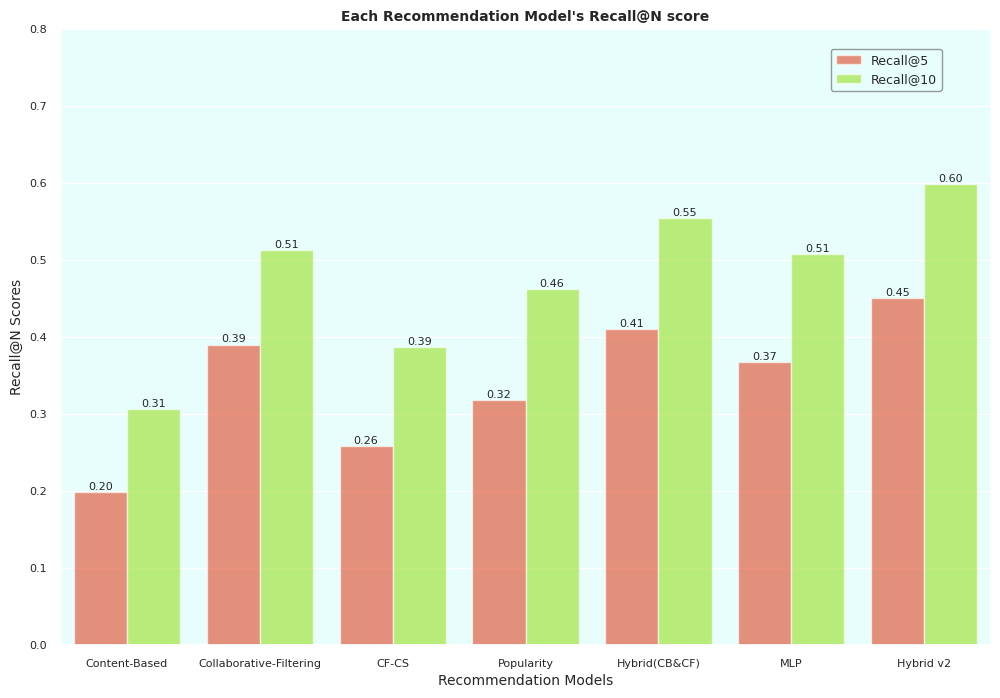

In [63]:
# Creating Bar Plot 

fig, ax = plt.subplots(figsize=(12,8))
bar = sns.barplot(data=models_score_df, x="model", y="score", hue="metric", alpha=.6, palette=bar_colors)

for i, (m, s) in  enumerate(zip(models_score_df["model"], models_score_df["score"])):
    offset = -.2 if i<=6 else .2
    plt.text(models_x_values[m] + offset, y=s+.003, s= f"{s:.2f}", ha="center", fontsize=8)

plt.yticks([i/10 for i in range(9)])
plt.xlabel("Recommendation Models", fontsize=10)
plt.ylabel("Recall@N Scores", fontsize=10)
plt.tick_params(axis="both", which="major", labelsize=8)
plt.title("Each Recommendation Model's Recall@N score", fontweight="bold", fontsize=10)

plt.legend(
    handles = [bar.patches[0], bar.patches[len(models_x_values)]],
    labels = ["Recall@5", "Recall@10"],
    loc = (.828, .9),
    fontsize = 9,
    edgecolor = "grey", 
)

plt.show()

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h2 align="center" ><font color="#FF0000">Summary of this Notebook</font></h2>

- In this Notebook I have implemented **Content-Based Filtering**, **Collaborative Filtering**, **Popularity Based** and **Hybrid (CB & CF)** Recommendation Systems.
- **Content-Based Filtering** is evaluated with **Cosine Similarities** where user's contents is stored in a Unit Vector and this Unit Vector is compared against all the contents to find similar non interacted contents for recommendation and it is evaluated at **Recall@5 = .199** and **Recall@10 = .307**.
- Then I implemented **Collaborative Filtering** with the help of **Singular Value Decomposition** which is evaluated at **Recall@5 = .39** and **Recall@10 = .513**.
- After that I implemented **Popularity Based RecSys** which recommended most popular non interacted contents to the user which is evaluated at **Recall@5 = .318** and **Recall@10 = .462**.
- Then it is turn of **Hybrid v1 RecSys of (CB & CF)** and strength of recommendations went through a weighted ensemble and this model is evaluated at **Recall@5 = .41** and **Recall@10 = .554** and it is top performing non **DNN** model in this notebook.
- After that I implement **DNN** based **MLP** and got **Recall@10** of **.56**. It is most powerful single model in this notebook.
- Then I tested Ensemble of both **Collaborative Filtering Models** and got **Recall@10** of **.57**.
- Finally I created **Hybrid v2** which comprise of ensemble of **Collaborative Filtering with SVD** with **Neural Collaborative Filtering with MLP** and **Content-Based Filtering** which scored at **Recall@10 =** **.6** and observed a massive increase in **Recall@5&10** by **.05** compared to **Hybrid v1** which makes it most performant Recommendation System in this Notebook.

<div style="border-radius:10px; font-size:100%; padding:15px; color:#000000; background-color:#FECEA8">

<h2 align="center" ><font color="#FF0000">End of Notebook</font></h2>
